<a href="https://colab.research.google.com/github/momo25bend/streamsentinel/blob/main/streamsentinel_J3_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# StreamSentinel · Notebook J3 : détection d'objets

Trois sources complémentaires, réunies dans un format commun :

| Bloc | Méthode | Détections |
|---|---|---|
| A | YOLO entraîné sur le dataset RF100-VL | bouteille, canette, emballage, papier |
| B | Modèle Roboflow existant (API) | poisson mort |
| C | OWLv2 zero-shot (phrases en anglais) | buse de rejet, ouvrage, faune, débris sanitaire |

Puis un **garde-fou** : les détections sont confrontées au masque d'eau du J1.

⚙️ `Exécution > Modifier le type d'exécution > GPU T4`

⏱️ La section A (entraînement) prend 30 à 60 minutes. Elle se saute
automatiquement si le modèle est déjà sur votre Drive.

## 0. Installation, GPU, Drive

In [6]:
!pip install -q ultralytics roboflow transformers supervision

import torch, os, glob, json
import cv2
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Appareil utilisé :", device)

from google.colab import drive, userdata
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/streamsentinel"
DOSSIERS = {k: f"{BASE}/{k}" for k in ["photos", "masques", "resultats", "modeles"]}
for d in DOSSIERS.values():
    os.makedirs(d, exist_ok=True)

ROBOFLOW_API_KEY = userdata.get("ROBOFLOW_API_KEY")

EXTENSIONS = ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG")
photos = sorted(p for ext in EXTENSIONS for p in glob.glob(f"{DOSSIERS['photos']}/{ext}"))
print(len(photos), "photos")

TAILLE_MAX = 1024

def charger(chemin):
    img = ImageOps.exif_transpose(Image.open(chemin)).convert("RGB")
    img.thumbnail((TAILLE_MAX, TAILLE_MAX))
    return img

ERROR: Ignored the following yanked versions: 0.9.0, 0.9.1, 0.9.2, 0.9.3, 0.9.4, 0.9.5, 0.9.6, 0.9.7rc2, 0.9.7, 0.9.8, 0.9.9rc23, 0.9.9, 0.9.10rc3, 0.9.10, 0.9.11rc1, 0.9.11rc2, 0.9.11, 0.9.12rc1, 0.9.12rc3, 0.9.12, 0.9.13, 0.9.14, 0.9.15rc1, 0.9.15, 0.9.16, 0.9.17
ERROR: Ignored the following versions that require a different python version: 0.10.0 Requires-Python <3.12,>=3.8; 0.11.0 Requires-Python <3.12,>=3.8; 0.11.1 Requires-Python <3.12,>=3.8; 0.11.2 Requires-Python <3.12,>=3.8; 0.12.0 Requires-Python <3.12,>=3.8; 0.12.1 Requires-Python <3.12,>=3.8; 0.13.0 Requires-Python <3.12,>=3.8; 0.14.0 Requires-Python <3.12,>=3.8; 0.14.1 Requires-Python <3.12,>=3.8; 0.15.0 Requires-Python <3.12,>=3.8; 0.15.1 Requires-Python <3.12,>=3.8; 0.15.2 Requires-Python <3.12,>=3.8; 0.16.0 Requires-Python <3.12,>=3.8; 0.16.2 Requires-Python <3.12,>=3.8; 0.16.3 Requires-Python <3.12,>=3.8; 0.17.0 Requires-Python <3.12,>=3.8; 0.17.1 Requires-Python <3.12,>=3.8; 0.18.0 Requires-Python <3.12,>=3.8; 0.18.1 

In [9]:
!pip install -q roboflow ultralytics supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.0/385.0 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 9.6 MB/s eta 0:00:00


In [11]:
import roboflow, ultralytics
print("roboflow", roboflow.__version__,"| ultralytics", ultralytics.__version__)

roboflow 1.5.0 | ultralytics 8.4.156


## A. Détecteur de déchets (entraînement)

On part de `yolo11s`, déjà entraîné sur des objets courants, et on l'affine sur
le dataset de déchets flottants. C'est le *fine-tuning* : bien plus rapide qu'un
entraînement de zéro, et bien meilleur avec peu de données.

Le modèle est enregistré sur le Drive : il survit à la fin de session.

In [12]:
CHEMIN_MODELE = f"{DOSSIERS['modeles']}/dechets/weights/best.pt"

if os.path.exists(CHEMIN_MODELE):
    print("Modèle déjà entraîné :", CHEMIN_MODELE)
else:
    from roboflow import Roboflow
    from ultralytics import YOLO

    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    dechets = (rf.workspace("rf100-vl").project("floating-waste-8deje-lrbq")
                 .version(2).download("yolov8", location="/content/datasets/dechets"))

    YOLO("yolo11s.pt").train(
        data=f"{dechets.location}/data.yaml",
        epochs=40,        # un passage complet sur le dataset = 1 epoch
        imgsz=640,
        batch=16,
        patience=10,      # arrêt si aucune amélioration pendant 10 epochs
        project=DOSSIERS["modeles"],
        name="dechets",
        exist_ok=True,
    )
    print("Entraînement terminé :", CHEMIN_MODELE)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/datasets/dechets in yolov8:: 100%|██████████| 5880/5880 [00:02<00:00, 2794.26it/s]


Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/dechets/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=dechets, nbs=64, nms=None, opset=None, opt

### Charger le modèle et lire ses performances

In [13]:
from ultralytics import YOLO

modele_dechets = YOLO(CHEMIN_MODELE)
print("Classes apprises :", modele_dechets.names)

# mAP50 par classe sur le jeu de validation
try:
    metriques = modele_dechets.val(data="/content/datasets/dechets/data.yaml", verbose=False)
    print("mAP50 global :", round(float(metriques.box.map50), 3))
    for i, nom in modele_dechets.names.items():
        print(f"  {nom} : {round(float(metriques.box.maps[i]), 3)}")
except Exception as e:
    print("Validation non disponible (dataset absent de cette session) :", type(e).__name__)

Classes apprises : {0: 'bottle', 1: 'can', 2: 'carton', 3: 'paper', 4: 'plastic'}
Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,414,735 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3146.6±589.8 MB/s, size: 245.2 KB)
val: Scanning /content/datasets/dechets/valid/labels.cache... 599 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 599/599 157.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 4.1it/s 9.2s
                   all        599       1741      0.843      0.749       0.79      0.474
Speed: 1.3ms preprocess, 5.6ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val
mAP50 global : 0.79
  bottle : 0.49
  can : 0.549
  carton : 0.385
  paper : 0.266
  plastic : 0.683


## B. Poissons morts : modèle existant via l'API Roboflow

Ce modèle est déjà entraîné (mAP50 annoncé à 88,8 %). On l'appelle par API :
rien à entraîner, mais chaque appel passe par Internet.

In [14]:
import requests, base64

MODELE_POISSONS = "dead-fish-ye77u/30"

def detecter_poissons(chemin, seuil=0.4):
    try:
        with open(chemin, "rb") as f:
            image = base64.b64encode(f.read()).decode()
        reponse = requests.post(
            f"https://serverless.roboflow.com/{MODELE_POISSONS}",
            params={"api_key": ROBOFLOW_API_KEY, "confidence": int(seuil * 100)},
            data=image,
            headers={"Content-Type": "application/x-www-form-urlencoded"},
            timeout=30,
        )
        reponse.raise_for_status()
        return [p for p in reponse.json().get("predictions", []) if p["confidence"] >= seuil]
    except Exception as e:
        print("API poissons indisponible :", type(e).__name__)
        return []

print(detecter_poissons(photos[0]))

[]


## C. OWLv2 : détection à partir de phrases

OWLv2 détecte un objet décrit **en texte**, sans entraînement. C'est ce qui
couvre les catégories pour lesquelles aucun dataset n'existe.

Les phrases sont en anglais et volontairement descriptives : « drain pipe
outlet on a river bank » marche mieux que « pipe ».

In [19]:
REQUETES = {
    "a drain pipe outlet": "buse_rejet",
    "a bird standing on the water": "faune",
    "a white wet wipe floating in the water": "debris_sanitaire",
}
PHRASES_OWL = list(REQUETES.keys())

# seuil par classe : le zero-shot est très bavard, on exige plus de certitude
SEUILS_OWL = {"buse_rejet": 0.30, "faune": 0.35, "debris_sanitaire": 0.30}
TAILLE_MAX_OWL = 0.25   # un objet qui couvre plus de 25 % de l'image n'en est pas un

@torch.no_grad()
def detecter_owl(img_pil, seuil_bas=0.25):
    entrees = owl_processor(text=[PHRASES_OWL], images=img_pil, return_tensors="pt").to(device)
    sorties = owl_model(**entrees)
    tailles = torch.tensor([img_pil.size[::-1]]).to(device)

    try:
        res = owl_processor.post_process_grounded_object_detection(
            outputs=sorties, target_sizes=tailles, threshold=seuil_bas)[0]
    except Exception:
        res = owl_processor.post_process_object_detection(
            outputs=sorties, target_sizes=tailles, threshold=seuil_bas)[0]

    aire_image = img_pil.size[0] * img_pil.size[1]
    objets = []
    for boite, score, etiquette in zip(res["boxes"], res["scores"], res["labels"]):
        phrase = PHRASES_OWL[int(etiquette)] if not isinstance(etiquette, str) else etiquette
        classe = REQUETES.get(phrase, phrase)
        score = float(score)
        if score < SEUILS_OWL.get(classe, 0.30):
            continue

        x1, y1, x2, y2 = boite.tolist()
        if (x2 - x1) * (y2 - y1) > TAILLE_MAX_OWL * aire_image:
            continue   # rectangle trop grand : c'est la scène, pas un objet

        objets.append({"classe": classe, "confiance": round(score, 2),
                       "boite": [round(v, 1) for v in (x1, y1, x2, y2)],
                       "source": "owlv2"})
    return objets

print(len(detecter_owl(charger(photos[0]))), "détections OWLv2")

0 détections OWLv2


## D. Masque d'eau (repris du J1)

Le masque sert de **garde-fou** : un poisson mort détecté hors de l'eau (sur un
étal, dans une main) est écarté. Les déchets, eux, sont conservés même sur la
berge : c'est de la pollution dans les deux cas.

In [16]:
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

SEG_ID = "nvidia/segformer-b2-finetuned-ade-512-512"
seg_processor = SegformerImageProcessor.from_pretrained(SEG_ID)
seg_model = SegformerForSemanticSegmentation.from_pretrained(SEG_ID).to(device).eval()

CLASSES_EAU = ["water", "sea", "river", "lake", "waterfall", "swimming pool"]
table_eau = np.zeros(len(seg_model.config.id2label), dtype=np.uint8)
for idx, nom in seg_model.config.id2label.items():
    if nom.split(";")[0].strip().lower() in CLASSES_EAU:
        table_eau[int(idx)] = 1

@torch.no_grad()
def masque_eau(img_pil, part_min=0.01):
    entrees = seg_processor(images=img_pil, return_tensors="pt").to(device)
    seg = seg_processor.post_process_semantic_segmentation(
        seg_model(**entrees), target_sizes=[img_pil.size[::-1]])[0]
    eau = table_eau[seg.cpu().numpy().astype(np.int64)]

    eau = cv2.morphologyEx(eau, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
    n, etiquettes, stats, _ = cv2.connectedComponentsWithStats(eau)
    propre = np.zeros_like(eau)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= part_min * eau.size:
            propre[etiquettes == i] = 1
    return propre

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  110MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

## E. Fusion des trois sources

Toutes les détections sont ramenées au même format : classe française,
confiance, coins du rectangle, source. YOLO donne les coins, Roboflow donne le
centre et la taille : on convertit.

In [28]:
TRADUCTION = {"bottle": "bouteille", "can": "canette", "plastic": "emballage",
              "carton": "emballage", "paper": "papier", "deadfish": "poisson_mort"}

# classes dont la détection n'a de sens que dans l'eau
EXIGE_EAU = {"poisson_mort", "debris_sanitaire"}

def _dans_eau(boite, eau, taille_img, marge=31):
    if eau is None:
        return None
    H, W = eau.shape
    zone_large = cv2.dilate(eau, np.ones((marge, marge), np.uint8))
    sx, sy = W / taille_img[0], H / taille_img[1]
    x1, y1, x2, y2 = boite
    extrait = zone_large[int(y1 * sy):int(y2 * sy) + 1, int(x1 * sx):int(x2 * sx) + 1]
    return bool(extrait.size and extrait.mean() > 0.3)

def detecter_objets(chemin, seuil=0.4, avec_owl=True):
    img = charger(chemin)
    eau = masque_eau(img)
    objets = []

    # A. déchets
    for boite in modele_dechets(img, conf=seuil, verbose=False)[0].boxes:
        nom = modele_dechets.names[int(boite.cls)]
        objets.append({"classe": TRADUCTION.get(nom, nom),
                       "confiance": round(float(boite.conf), 2),
                       "boite": [round(v, 1) for v in boite.xyxy[0].tolist()],
                       "source": "yolo"})

    # B. poissons morts (coordonnées centre+taille -> coins)
    #for p in detecter_poissons(chemin):
        #x, y, w, h = p["x"], p["y"], p["width"], p["height"]
        #objets.append({"classe": "poisson_mort", "confiance": round(p["confidence"], 2),
                      # "boite": [x - w / 2, y - h / 2, x + w / 2, y + h / 2],
                       #"source": "roboflow"})

    # C. zero-shot
    if avec_owl:
        objets += detecter_owl(img)

    # garde-fou
    gardes = []
    for o in objets:
        o["dans_eau"] = _dans_eau(o["boite"], eau, img.size)
        if o["classe"] in EXIGE_EAU and o["dans_eau"] is False:
            o["ecarte"] = "hors de l'eau"
            continue
        gardes.append(o)

    return {"photo": os.path.basename(chemin), "objets": gardes,
            "part_eau": round(float(eau.mean()), 3)}

### Visualisation

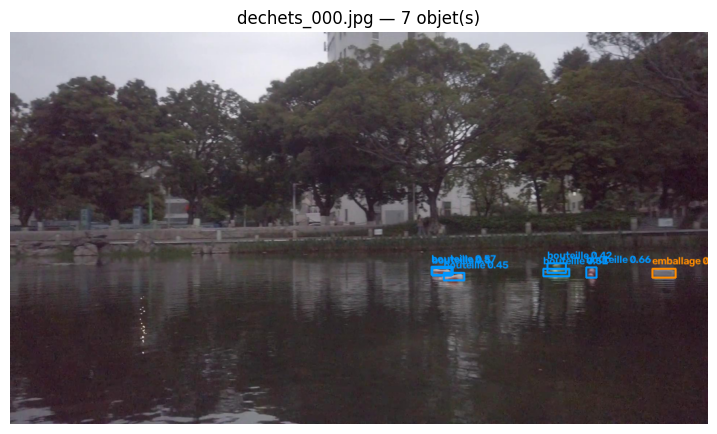

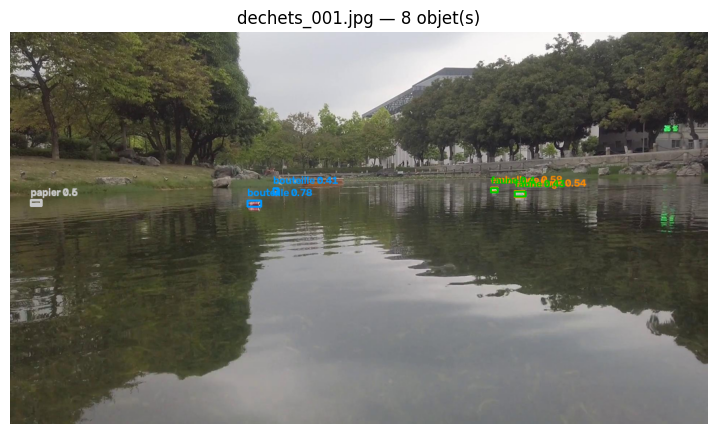

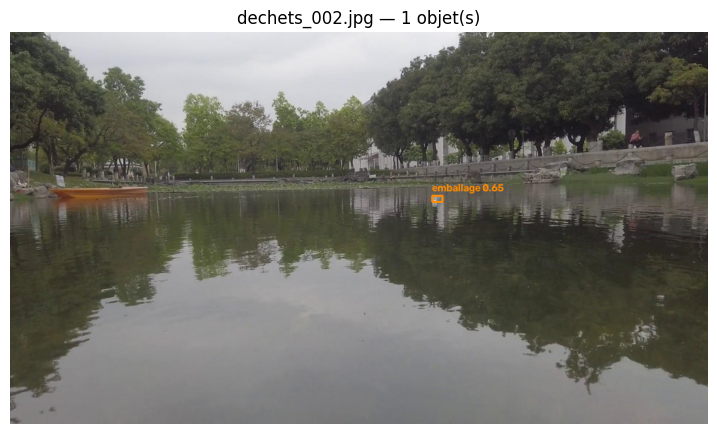

In [21]:
COULEURS = {"bouteille": (0, 150, 255), "canette": (0, 200, 200), "emballage": (255, 140, 0),
            "papier": (200, 200, 200), "poisson_mort": (255, 0, 0), "buse_rejet": (255, 0, 255),
            "ouvrage": (150, 100, 50), "faune": (0, 200, 0), "debris_sanitaire": (255, 255, 0)}

def afficher_detections(chemin, resultat):
    image = np.array(charger(chemin))
    for o in resultat["objets"]:
        x1, y1, x2, y2 = [int(v) for v in o["boite"]]
        couleur = COULEURS.get(o["classe"], (255, 255, 255))
        cv2.rectangle(image, (x1, y1), (x2, y2), couleur, 2)
        cv2.putText(image, f"{o['classe']} {o['confiance']}", (x1, max(y1 - 6, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, couleur, 2)
    plt.figure(figsize=(9, 6))
    plt.imshow(image); plt.axis("off")
    plt.title(f"{resultat['photo']} — {len(resultat['objets'])} objet(s)")
    plt.show()

for p in [x for x in photos if "dechets" in os.path.basename(x)][:3]:
    afficher_detections(p, detecter_objets(p))

## F. Passage sur tout le jeu

Les appels OWLv2 et Roboflow sont lents : comptez 3 à 6 secondes par photo.

In [32]:
from tqdm.auto import tqdm

resultats_j3, ignorees = [], []
for p in tqdm(photos):
    try:
        resultats_j3.append(detecter_objets(p))
    except Exception as e:
        ignorees.append((os.path.basename(p), type(e).__name__))

with open(f"{DOSSIERS['resultats']}/resultats_j3.json", "w", encoding="utf-8") as f:
    json.dump(resultats_j3, f, ensure_ascii=False, indent=2)

import collections
compte = collections.Counter(o["classe"] for r in resultats_j3 for o in r["objets"])
print(f"{len(resultats_j3)} photos, {len(ignorees)} ignorées")
print("Détections par classe :", dict(compte))

  0%|          | 0/51 [00:00<?, ?it/s]

50 photos, 1 ignorées
Détections par classe : {'emballage': 14, 'bouteille': 48, 'papier': 6, 'faune': 18, 'canette': 4, 'buse_rejet': 2}


### Combien de détections par photo ?

In [33]:
import pandas as pd

lignes = [{"photo": r["photo"],
           "objets": len(r["objets"]),
           "classes": ", ".join(sorted({o["classe"] for o in r["objets"]})) or "-"}
          for r in resultats_j3]

tableau = pd.DataFrame(lignes)
display(tableau[~tableau["photo"].str.startswith("dechets")])
print("Moyenne sur les photos de déchets :",
      round(tableau[tableau["photo"].str.startswith("dechets")]["objets"].mean(), 2))

,photo,objets,classes
0,berge_betonnee_00.jpg,0,-
1,berge_betonnee_01.jpg,0,-
2,berge_betonnee_02.jpg,0,-
3,berge_naturelle_00.jpg,0,-
4,berge_naturelle_01.jpg,0,-
5,berge_naturelle_02.jpg,0,-
36,eau_boueuse_00.jpg,0,-
37,eau_boueuse_01.jpg,0,-
38,eau_boueuse_02.jpg,1,papier
39,eau_verte_01.jpg,0,-


Moyenne sur les photos de déchets : 3.03


berge_betonnee_01.jpg []


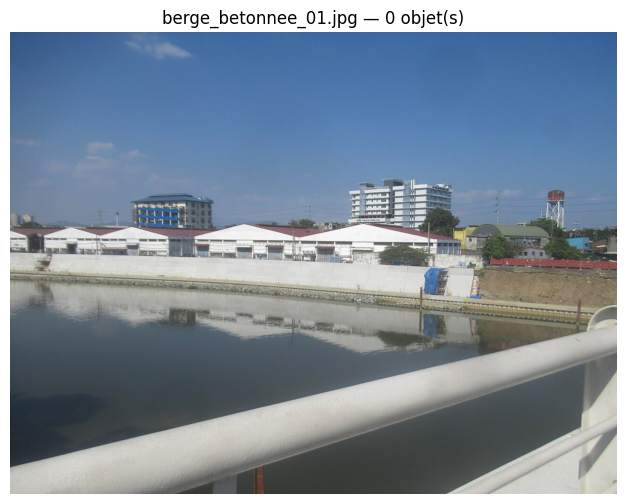

Introuvable : eau_verte_00.jpg


In [31]:
for nom in ["berge_betonnee_01.jpg", "eau_verte_00.jpg"]:
    trouves = [x for x in resultats_j3 if x["photo"] == nom]
    if not trouves:
        print("Introuvable :", nom)
        continue
    r = trouves[0]
    print(nom, [(o["classe"], o["confiance"], o["source"]) for o in r["objets"]])
    afficher_detections(f"{DOSSIERS['photos']}/{nom}", r)

## G. Réglage des seuils

Les détecteurs zero-shot produisent beaucoup de fausses détections à seuil bas.
Regardez les photos affichées en E : si une classe apparaît partout, remontez
son seuil ; si elle n'apparaît jamais, descendez-le.

Notez les seuils retenus dans le README : c'est une décision de conception,
pas un détail technique.

In [ ]:
# Vue des confiances par classe, pour choisir les seuils
scores = {}
for r in resultats_j3:
    for o in r["objets"]:
        scores.setdefault(o["classe"], []).append(o["confiance"])

for classe, valeurs in sorted(scores.items()):
    valeurs = sorted(valeurs)
    print(f"{classe:18s} n={len(valeurs):3d}  min={valeurs[0]:.2f}  "
          f"médiane={valeurs[len(valeurs)//2]:.2f}  max={valeurs[-1]:.2f}")